In [3]:
# import  os
# num_cores = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = num_cores
# os.environ["OMP_NUM_THREADS"] = num_cores
# os.environ["MKL_NUM_THREADS"] = num_cores

In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
from scipy.sparse.linalg import eigsh
import utils_2Q_gate_zp as ut
from joblib import Parallel, delayed
from IPython.display import display, Math
# ut.set_fig_font() ### Set various sizes in plotting
import networkx as nx
from multiprocessing import Pool
import pandas as pd

In [ ]:
truncation = 1000
ncut=90
phi_cut=300

EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, phi_cut)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=ncut, truncated_dim=truncation)
# print('zero_pi.ncut=',zero_pi.ncut, ', zero_pi.grid.pt_count=',zero_pi.grid.pt_count )
n_Theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truncation)
n_Phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truncation)
n_phi = 2*np.pi * qt.Qobj(n_Phi)
n_theta = 2*np.pi * qt.Qobj(n_Theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=truncation)
evals = evals - evals[0]

In [2]:
# hspace_theta2 = [0, 1, 2, 4, 5, 7, 8, 11, 12, 17, 18, 25, 32, 38, 46]
truc1, truc_tot, charge_pick  = 400, 500, True

In [3]:
folder = f'two_qubit_data_truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
eval_tot = pd.read_csv(folder+ 'eval_tot.txt').to_numpy().flatten()
n_theta0_dress = pd.read_csv(folder+ 'n_theta0_dress.txt').to_numpy()
n_theta1_dress = pd.read_csv(folder+ 'n_theta1_dress.txt').to_numpy()
hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()

In [4]:
truc_tot_2 = 500
truc_list = np.arange(truc_tot_2)
hspace_full = hspace_full[:truc_tot_2]
eval_tot = eval_tot[:truc_tot_2]

n_theta0_dress = ut.truncate_2(n_theta0_dress, truc_list)
n_theta1_dress = ut.truncate_2(n_theta1_dress, truc_list)
print(np.shape(n_theta0_dress))

(500, 500)


In [5]:
# args_all = ut.get_operator_two_zeropi_v2(truc1=truc1, truc_tot=truc_tot, charge_pick=charge_pick)
# [hspace_0, hspace_1, top3_index, top3_overlap,
# n_theta0_dress, n_theta1_dress, eval_tot, index_state] = args_all
hspace_logi = ['0-0', '0-2', '2-0', '2-2']
hspace_index = [hspace_full.index(i) for i in hspace_logi]

In [6]:
print('index_state :')
dim = 10
data = hspace_full
for i in range(0, len(data), dim):  # Step size of 10
    print(i,", ".join(f"'{x}'" for x in data[i:i + dim]), ',')

if charge_pick==False:
    thresh = 1e-2
    for s in hspace_index:
        for i in range(truc_tot):
            if np.abs(n_theta0_dress[s, i]) > thresh and i not in hspace_index:
                hspace_index.append(i)
    hspace_index.sort()
    print('threshold=', thresh)
    print('truncation_tot =', truc_tot, ', truncation_2nd_tot =', len(hspace_index))
    print('index_state after charge pick :')

    hspace_tot = np.array(hspace_full)[hspace_index]
    dim = 10
    data = hspace_tot
    for i in range(0, len(data), dim):  # Step size of 10
        print(", ".join(f"'{x}'" for x in data[i:i + dim]), ',')

index_state :
0 '0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
10 '5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '0-9', '2-4', '9-0' ,
20 '1-5', '5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '0-13', '0-16' ,
30 '8-1', '4-4', '13-0', '15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5' ,
40 '0-18', '2-9', '1-12', '0-20', '0-21', '18-0', '9-2', '12-1', '5-5', '0-24' ,
50 '4-8', '1-13', '20-0', '8-4', '1-16', '22-0', '2-12', '13-1', '24-0', '0-25' ,
60 '15-1', '0-26', '5-8', '4-9', '12-2', '2-13', '9-4', '2-16', '8-5', '25-0' ,
70 '13-2', '26-0', '1-18', '15-2', '0-28', '5-9', '4-12', '28-0', '0-30', '18-1' ,
80 '12-4', '9-5', '1-20', '1-21', '0-33', '8-8', '0-34', '0-35', '1-24', '2-18' ,
90 '0-36', '20-1', '4-13', '22-1', '4-16', '30-0', '13-4', '5-12', '15-4', '24-1' ,
100 '33-0', '2-20', '18-2', '34-0', '2-21', '8-9', '35-0', '1-25', '9-8', '1-26' ,
110 '0-39', '12-5', '2-24', '37-0', '5-13', '20-2', '5-16', '22-2', '13-5', '25-1' ,
120 '0-42', '26-1', '24-2

In [9]:
W_20_50 = eval_tot[hspace_full.index('5-0')] - eval_tot[hspace_full.index('2-0')]
detune = 0. # Assume very close to resonance driving -- not actually true
wd = W_20_50 + detune
core_states = hspace_logi + ['5-0']
print('len(eval_tot)=', len(eval_tot))
print('len(index_state)=', len(hspace_full))
# print('index_state=', index_state)

len(eval_tot)= 2000
len(index_state)= 2000


### Truncation Estimate

In [10]:
drive_term = n_theta1_dress
A = 0.02
######
# max_n_ij = np.max(drive_term) # Normalize based on n
population_rate = np.zeros((truc_tot, truc_tot))
population_rate_log = np.zeros((truc_tot, truc_tot))
rabi_df = []
G = nx.DiGraph()
for i, s_i in enumerate(hspace_full):
    for j, s_j in enumerate(hspace_full):
        if i < j:
            n_ij = drive_term[i, j]
            # normalization =  n_ij/max_n_ij
            delta = abs(wd - (eval_tot[j] - eval_tot[i]))
            population_rate[i,j] = ((A*n_ij)**2) / ((A*n_ij)**2 + delta**2)
            if population_rate[i,j] > 0:
                population_rate_log[i, j] = -np.log(population_rate[i,j])
                G.add_edge(s_i, s_j, weight=population_rate_log[i, j]) # Construct the graph

    rabi_df.append({"order": i, "i": s_i})
rabi_df = pd.DataFrame(rabi_df)
rabi_df.index = rabi_df["i"]
print('shape(population_rate_log)=', np.shape(population_rate_log))
rabi_df

shape(population_rate_log)= (2000, 2000)


,order,i
i,,
0-0,0,0-0
0-1,1,0-1
1-0,2,1-0
0-2,3,0-2
2-0,4,2-0
...,...,...
161-1,1995,161-1
90-18,1996,90-18
81-26,1997,81-26


In [11]:
if truc_tot < 30:
    nx.draw(G, pos=nx.shell_layout(G), with_labels=True)
print(G['0-0']['1-0'])
qt.Qobj(population_rate_log)

{'weight': 3.7918986828366736}


Quantum object: dims = [[2000], [2000]], shape = (2000, 2000), type = oper, isherm = False
Qobj data =
[[ 0.          3.39481361  3.79189868 ...  0.          0.
  47.00590793]
 [ 0.          0.          0.         ... 42.57180728 43.35978095
   0.        ]
 [ 0.          0.          0.         ... 46.64957896 44.33015802
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
  13.77953634]
 [ 0.          0.          0.         ...  0.          0.
   9.36854763]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]

In [12]:
def shortest_path_to_core(target):
    shortest_path = ""
    shortest_path_len = np.inf
    for source in core_states[:-1]:
        if nx.has_path(G, source, target):
            path = nx.shortest_path(G, source=source, target=target,
                                    weight="weight")
            path_len = nx.shortest_path_length(G, source=source, target=target,
                                                weight="weight")
        if path_len < shortest_path_len:
            shortest_path_len = path_len
            shortest_path = ",".join([str(x) for x in path])
    return target, (shortest_path_len, shortest_path)

cutoff = 2
def all_path_to_core(target):
    path_tot = []
    if target in core_states:
        weight_tot = 1
    else:
        weight_tot = 0
        for source in core_states:
            for path in nx.all_simple_paths(G, source, target, cutoff=cutoff):
                weight_tot += np.exp( - nx.path_weight(G, path,'weight') )
                path_tot.append(path)
    return target, (weight_tot, path_tot)
print(shortest_path_to_core('1-0'))
print(all_path_to_core('0-4'))
print(all_path_to_core('0-1'))

('1-0', (3.7918986828366736, '0-0,1-0'))
('0-4', (0.0006242331278032746, [['0-0', '0-1', '0-4'], ['0-0', '1-0', '0-4']]))
('0-1', (0.03354680642380842, [['0-0', '0-1']]))


In [13]:
target = '0-4'
source = '0-0'
paths = nx.all_simple_paths(G, source=source, target=target, cutoff=cutoff)
weight_tot = sum([np.exp(- nx.path_weight(G, path=path, weight='weight'))
                   for path in paths])
print(weight_tot)
for path in nx.all_simple_paths(G, source=source, target=target, cutoff=cutoff):
    print(path)

0.0006242331278032746
['0-0', '0-1', '0-4']
['0-0', '1-0', '0-4']


In [14]:
# Find shortest path for each node
pool = Pool(processes=150)
shortest_path = {}
rabi_df["path"] = ""
rabi_df["path_len"] = 1.0
for idx, path in tqdm(pool.imap_unordered(shortest_path_to_core, hspace_full),
                total=truc_tot):
    shortest_path[idx[0]] = path
    rabi_df.at[idx, "path"] = path[1]
    rabi_df.at[idx, "path_len"] = np.exp(-path[0])

df_short = rabi_df.sort_values("path_len", ascending=False)
print('shortest_path:')
df_short.iloc[:30]

100%|██████████| 2000/2000 [01:07<00:00, 29.70it/s]

shortest_path:


,order,i,path,path_len
i,,,,
0-0,0,0-0,0-0,1.000000
2-2,13,2-2,2-2,1.000000
0-2,3,0-2,0-2,1.000000
2-0,4,2-0,2-0,1.000000
5-0,10,5-0,"2-0,5-0",1.000000
5-2,27,5-2,"2-2,5-2",0.327869
5-1,21,5-1,"2-0,5-0,5-1",0.063677
0-1,1,0-1,"0-0,0-1",0.033547
2-1,9,2-1,"2-0,2-1",0.027697


In [15]:
df_short_200 = df_short.iloc[:200].sort_values("order", ascending=True)
print('state_short :')
data = df_short_200['i']
for i in range(0, len(data), dim):  # Step size of 10
    print(", ".join(f"'{x}'" for x in data[i:i + dim]), ',')

state_short :
'0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
'5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '0-9', '2-4', '9-0' ,
'1-5', '5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '0-13', '0-16' ,
'8-1', '4-4', '13-0', '15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5' ,
'0-18', '2-9', '1-12', '0-20', '0-21', '18-0', '9-2', '12-1', '5-5', '0-24' ,
'4-8', '1-13', '20-0', '8-4', '1-16', '22-0', '2-12', '13-1', '0-25', '15-1' ,
'0-26', '5-8', '4-9', '12-2', '2-13', '9-4', '2-16', '8-5', '25-0', '13-2' ,
'1-18', '15-2', '0-28', '5-9', '4-12', '0-30', '18-1', '12-4', '9-5', '1-20' ,
'1-21', '0-33', '8-8', '0-34', '1-24', '2-18', '0-36', '20-1', '4-13', '22-1' ,
'4-16', '13-4', '5-12', '15-4', '24-1', '33-0', '2-20', '18-2', '2-21', '8-9' ,
'1-25', '9-8', '0-39', '12-5', '2-24', '5-13', '20-2', '5-16', '13-5', '25-1' ,
'0-42', '15-5', '4-18', '2-25', '39-0', '2-26', '8-12', '9-9', '18-4', '12-8' ,
'1-30', '4-20', '0-45', '4-21', '13-8', '1-33', '8-13', '20-4',

In [16]:
# Find all_path_to_core
pool = Pool(processes=150)
shortest_path = {}
rabi_df["path"] = ""
rabi_df["path_len"] = 1.0
for idx, path in tqdm(pool.imap_unordered(all_path_to_core, hspace_full),
                total=truc_tot):
    shortest_path[idx[0]] = path
    rabi_df.at[idx, "path"] = path[1]
    rabi_df.at[idx, "path_len"] = path[0]

df_all = rabi_df.sort_values("path_len", ascending=False)
print('all_path -- cutoff=', cutoff)
df_all.iloc[:30]

100%|██████████| 2000/2000 [00:05<00:00, 394.17it/s]

all_path -- cutoff= 2


,order,i,path,path_len
i,,,,
0-0,0,0-0,[],1.000000
2-0,4,2-0,[],1.000000
5-0,10,5-0,[],1.000000
2-2,13,2-2,[],1.000000
0-2,3,0-2,[],1.000000
5-2,27,5-2,"[[0-0, 5-2], [0-2, 5-2], [2-0, 5-2], [2-2, 5-2...",0.327869
5-1,21,5-1,"[[0-0, 0-1, 5-1], [0-0, 1-0, 5-1], [0-0, 0-5, ...",0.127420
0-1,1,0-1,"[[0-0, 0-1]]",0.033547
2-1,9,2-1,"[[0-0, 2-1], [0-2, 2-1], [2-0, 2-1]]",0.027697


In [17]:
df_all_200 = df_all.iloc[:200].sort_values("order", ascending=True)
print('state_all :')
data = df_all_200['i']
for i in range(0, len(data), dim):  # Step size of 10
    print(", ".join(f"'{x}'" for x in data[i:i + dim]), ',')

state_all :
'0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
'5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '0-9', '2-4', '9-0' ,
'1-5', '5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '0-13', '0-16' ,
'8-1', '4-4', '13-0', '15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5' ,
'0-18', '2-9', '1-12', '0-20', '0-21', '18-0', '9-2', '12-1', '5-5', '0-24' ,
'4-8', '1-13', '20-0', '8-4', '1-16', '22-0', '2-12', '13-1', '0-25', '15-1' ,
'0-26', '5-8', '4-9', '12-2', '2-13', '9-4', '2-16', '8-5', '25-0', '13-2' ,
'1-18', '15-2', '5-9', '4-12', '0-30', '18-1', '12-4', '9-5', '1-20', '1-21' ,
'0-33', '8-8', '0-34', '0-35', '1-24', '2-18', '0-36', '5-12', '15-4', '24-1' ,
'2-20', '18-2', '2-21', '8-9', '1-25', '9-8', '1-26', '0-39', '12-5', '2-24' ,
'5-13', '5-16', '22-2', '0-42', '24-2', '15-5', '2-25', '2-26', '8-12', '9-9' ,
'18-4', '0-44', '12-8', '1-30', '0-45', '0-46', '1-33', '8-16', '22-4', '4-24' ,
'5-18', '1-34', '15-8', '2-28', '9-12', '24-4', '12-9', '33-1', '

In [39]:
aa = df_all_200['i'].to_numpy().tolist()
index = [hspace_full.index(i) for i in aa]
index

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 72,
 73,
 75,
 76,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 97,
 98,
 99,
 101,
 102,
 104,
 105,
 107,
 108,
 109,
 110,
 111,
 112,
 114,
 116,
 117,
 120,
 122,
 123,
 125,
 127,
 128,
 129,
 130,
 133,
 134,
 136,
 138,
 140,
 143,
 146,
 147,
 148,
 150,
 151,
 153,
 156,
 157,
 158,
 160,
 163,
 164,
 165,
 166,
 167,
 170,
 172,
 173,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 185,
 187,
 193,
 199,
 204,
 208,
 209,
 210,
 227,
 236,
 243,
 257,
 260,
 263,
 269,
 271,
 274,
 276,
 278,
 284,
 285,
 295,
 303,
 304,
 310,
 322,
 327,
 329,
 332,
 333,
 348,
 364,
 366,
 379,
 387,
 391,
 392,
 401,
 403,
 4

In [31]:
df_all_200 = df_all.iloc[:200].sort_values("order", ascending=True)
print('state_all :')
data = df_all_200['i']
for i in range(0, len(data), dim):  # Step size of 10
    print(", ".join(f"'{x}'" for x in data[i:i + dim]), ',')

state_all :
'0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
'5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '0-9', '2-4', '9-0' ,
'1-5', '5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '0-13', '0-16' ,
'8-1', '4-4', '13-0', '15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5' ,
'0-18', '2-9', '1-12', '0-20', '0-21', '18-0', '9-2', '12-1', '5-5', '0-24' ,
'4-8', '1-13', '20-0', '8-4', '1-16', '22-0', '2-12', '13-1', '0-25', '15-1' ,
'0-26', '5-8', '4-9', '12-2', '2-13', '9-4', '2-16', '8-5', '25-0', '13-2' ,
'1-18', '15-2', '5-9', '4-12', '0-30', '18-1', '12-4', '9-5', '1-20', '1-21' ,
'0-33', '8-8', '0-34', '0-35', '1-24', '2-18', '0-36', '5-12', '15-4', '24-1' ,
'2-20', '18-2', '2-21', '8-9', '1-25', '9-8', '1-26', '0-39', '12-5', '2-24' ,
'5-13', '5-16', '22-2', '0-42', '24-2', '15-5', '2-25', '2-26', '8-12', '9-9' ,
'18-4', '0-44', '12-8', '1-30', '0-45', '0-46', '1-33', '8-16', '22-4', '4-24' ,
'5-18', '1-34', '15-8', '2-28', '9-12', '24-4', '12-9', '33-1', '

In [19]:
list1 = df_short_200['i']
list2 = df_all_200['i']
common_elements = [item for item in list1 if item in list2]
only_in_list1 = [item for item in list1 if item not in list2]
only_in_list2 = [item for item in list2 if item not in list1]
unique_elements = only_in_list1 + only_in_list2

# print("Common elements:", common_elements)
print("Only in state_short:", len(only_in_list1), only_in_list1)
print("Only in state_all:", len(only_in_list2), only_in_list2)
# print("Unique elements:", unique_elements)


Only in state_short: 54 ['0-28', '20-1', '4-13', '22-1', '4-16', '13-4', '33-0', '20-2', '13-5', '25-1', '4-18', '39-0', '4-20', '4-21', '13-8', '8-13', '20-4', '1-36', '46-0', '20-5', '25-4', '15-9', '8-18', '12-12', '18-8', '54-0', '13-12', '8-21', '12-16', '20-8', '4-30', '22-8', '8-24', '15-12', '9-18', '18-9', '13-16', '33-4', '15-13', '44-1', '35-4', '41-2', '9-21', '46-1', '20-9', '12-18', '13-20', '8-34', '4-46', '24-13', '44-4', '9-30', '30-9', '13-25']
Only in state_all: 54 ['0-35', '1-26', '22-2', '24-2', '0-44', '0-46', '0-53', '13-9', '1-39', '37-1', '0-54', '0-55', '0-57', '0-59', '1-45', '2-42', '0-65', '2-44', '15-16', '9-24', '2-46', '0-68', '5-35', '0-73', '2-53', '9-26', '0-78', '18-16', '4-44', '2-54', '2-55', '2-57', '5-42', '2-59', '0-83', '2-60', '5-44', '8-39', '9-34', '9-35', '5-46', '2-64', '5-52', '5-53', '2-66', '2-68', '5-55', '2-73', '2-76', '5-59', '2-78', '5-65', '2-83', '5-68']


In [20]:
print('cutoff=', cutoff)
target = '5-2'
print(shortest_path_to_core(target))
idx, path = all_path_to_core(target)
for i in path[1]:
    print(i)


cutoff= 2


('5-2', (1.1151426188367475, '2-2,5-2'))
['0-0', '5-2']
['0-2', '5-2']
['2-0', '5-2']
['2-2', '5-2']
['5-0', '2-2', '5-2']
['5-0', '0-9', '5-2']
['5-0', '2-4', '5-2']
['5-0', '9-0', '5-2']
['5-0', '1-5', '5-2']
['5-0', '5-1', '5-2']
['5-0', '4-2', '5-2']
['5-0', '0-12', '5-2']
['5-0', '1-8', '5-2']
['5-0', '12-0', '5-2']


In [21]:
print('cutoff=', cutoff)
target = '5-2'
print(shortest_path_to_core(target))
idx, path = all_path_to_core(target)
for i in path[1]:
    print(i)


cutoff= 2


('5-2', (1.1151426188367475, '2-2,5-2'))
['0-0', '5-2']
['0-2', '5-2']
['2-0', '5-2']
['2-2', '5-2']
['5-0', '2-2', '5-2']
['5-0', '0-9', '5-2']
['5-0', '2-4', '5-2']
['5-0', '9-0', '5-2']
['5-0', '1-5', '5-2']
['5-0', '5-1', '5-2']
['5-0', '4-2', '5-2']
['5-0', '0-12', '5-2']
['5-0', '1-8', '5-2']
['5-0', '12-0', '5-2']


In [22]:
# Find shortest path for each node
pool = Pool(processes=150)
shortest_path = {}
rabi_df["path"] = ""
rabi_df["path_len"] = 0.0
rabi_df["degree"] = -1
for idx, path in tqdm(pool.imap_unordered(shortest_path_to_core, hspace_full),
                total=truc_tot):
    shortest_path[idx[0]] = path
    rabi_df.at[idx, "path"] = path[1]
    rabi_df.at[idx, "path_len"] = np.exp(-path[0])
    rabi_df.at[idx, "degree"] = path[1].count(",")

# print(population_rate[index_state.index('0-0'), index_state.index('0-1')] *
#       population_rate[index_state.index('0-1'), index_state.index('0-4')])
# print(population_rate[index_state.index('0-0'), index_state.index('1-0')] *
#       population_rate[index_state.index('1-0'), index_state.index('0-4')])
print(rabi_df.sort_values("path_len", ascending=False).iloc[:15])
# qt.Qobj(population_rate[:10,:10])

100%|██████████| 2000/2000 [01:04<00:00, 31.22it/s]

     order    i         path  path_len  degree
i                                             
0-0      0  0-0          0-0  1.000000       0
2-2     13  2-2          2-2  1.000000       0
0-2      3  0-2          0-2  1.000000       0
2-0      4  2-0          2-0  1.000000       0
5-0     10  5-0      2-0,5-0  1.000000       1
5-2     27  5-2      2-2,5-2  0.327869       1
5-1     21  5-1  2-0,5-0,5-1  0.063677       2
0-1      1  0-1      0-0,0-1  0.033547       1
2-1      9  2-1      2-0,2-1  0.027697       1
1-0      2  1-0      0-0,1-0  0.022553       1
0-5      8  0-5      0-2,0-5  0.014815       1
2-5     24  2-5      2-2,2-5  0.013941       1
1-2     11  1-2      0-2,1-2  0.013375       1
4-0      6  4-0  0-0,0-1,4-0  0.007902       2
1-5     20  1-5  0-2,0-5,1-5  0.006024       2


ValueError: The number of FixedLocator locations (15), usually from a call to set_ticks, does not match the number of labels (2000).

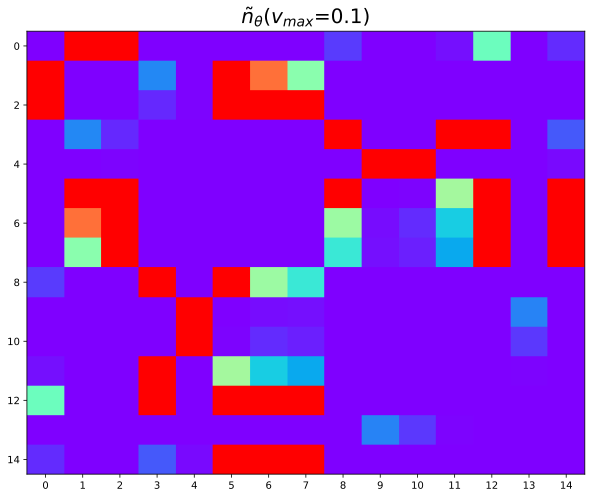

In [23]:
vmax = 0.1
truc_plot = 15
fig, ax = plt.subplots(figsize=(10,8))
plt.imshow(n_theta1_dress[:truc_plot,:truc_plot], vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$\tilde{n}_{\theta}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=20)
ax.set_xticks(np.arange(0, truc_plot, 1), hspace_full, fontsize=15)
ax.set_yticks(np.arange(0, truc_plot, 1), hspace_full, fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc_plot, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc_plot, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.5, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')